# 🌸 Test – Đánh giá mô hình Iris Dataset

**Môn:** Machine Learning  
**Bài toán:** Multiclass Classification – Phân loại 3 loại hoa Iris  
**Dataset:** iris.csv  
**4 features | 150 mẫu | 3 classes**

## Bước 10: Khởi tạo thí nghiệm Test

In [1]:
# ── Khai báo thư viện ───────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, pickle, warnings
from datetime import datetime
from openpyxl import load_workbook
warnings.filterwarnings('ignore')

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, RocCurveDisplay)

# ── Tham số thực nghiệm ─────────────────────────────────
# ============================================================
# TRAIN_DATA_NAME : tên data đã dùng để TRAIN (để biết load model nào)
# TEST_DATA_NAME  : tên data muốn TEST (có thể khác TRAIN)
TRAIN_DATA_NAME = 'iris'   # tên data đã dùng để TRAIN → load model từ model/{TRAIN_DATA_NAME}/
TEST_DATA_NAME  = 'iris'   # tên data muốn TEST → bắt buộc đã được EDA rồi
# ============================================================

BASE_DIR  = os.path.abspath(os.path.join(os.getcwd(), '..'))                     if os.path.basename(os.getcwd()) == 'prj' else os.getcwd()
EXP_DIR   = os.path.join(BASE_DIR, 'exps_')
MODEL_DIR = os.path.join(BASE_DIR, 'model', TRAIN_DATA_NAME)

BEST_MODEL_FILE = os.path.join(MODEL_DIR, f'{TRAIN_DATA_NAME}__best_model.pkl')
LOG_NAME = f'{TRAIN_DATA_NAME}__test_{TEST_DATA_NAME}_log.xlsx'
TEST_LOG = os.path.join(EXP_DIR, LOG_NAME)

TEST_FILES = {
    'raw'     : os.path.join(EXP_DIR, f'{TEST_DATA_NAME}_test_raw.csv'),
    'minmax'  : os.path.join(EXP_DIR, f'{TEST_DATA_NAME}_test_minmax.csv'),
    'standard': os.path.join(EXP_DIR, f'{TEST_DATA_NAME}_test_standard.csv'),
}

COLORS = ['#4C72B0','#DD8452','#55A868','#C44E52',
          '#8172B2','#937860','#DA8BC3','#8C8C8C','#CCB974','#64B5CD']
# Trọng số Composite – phải khớp với 02_train.ipynb
W_ACC = 0.4
W_F1  = 0.3
W_AUC = 0.3

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

print('✅ Khai báo thư viện và tham số xong!')
print(f'   Thời gian       : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'   TRAIN_DATA_NAME : {TRAIN_DATA_NAME}  → load model từ model/{TRAIN_DATA_NAME}/')
print(f'   TEST_DATA_NAME  : {TEST_DATA_NAME}   → đọc test từ exps_/{TEST_DATA_NAME}_test_*.csv')
print(f'   Model bundle    : {os.path.basename(BEST_MODEL_FILE)}')
print(f'   Kết quả lưu tại : {LOG_NAME}')


✅ Khai báo thư viện và tham số xong!
   Thời gian       : 2026-04-03 14:31:09
   TRAIN_DATA_NAME : iris  → load model từ model/iris/
   TEST_DATA_NAME  : iris   → đọc test từ exps_/iris_test_*.csv
   Model bundle    : iris__best_model.pkl
   Kết quả lưu tại : iris__test_iris_log.xlsx


Hai biến `TRAIN_DATA_NAME` và `TEST_DATA_NAME` có thể khác nhau —
đây là điểm linh hoạt của pipeline: model được train trên một bộ dữ liệu
có thể được kiểm tra trên một bộ dữ liệu khác (cross-dataset evaluation).
Khi cả hai cùng tên, đây là đánh giá hold-out thông thường trên cùng một bộ.

## Bước 11: Kiểm tra điều kiện trước khi test

Trước khi chạy test, pipeline kiểm tra ba điều kiện tiên quyết:
model đã được train và lưu, dữ liệu test đã qua bước EDA, và các file CSV test tồn tại.
Nếu thiếu bất kỳ điều kiện nào, notebook dừng lại ngay và in ra hướng dẫn khắc phục
thay vì chạy tiếp rồi báo lỗi khó hiểu ở giữa chừng.

In [2]:
# Kiểm tra 3 điều kiện:
# 1. Folder model/{TRAIN_DATA_NAME}/ tồn tại
# 2. File best_model.pkl đúng chuẩn bundle đã tồn tại
# 3. Bộ dữ liệu test đã được EDA và có đủ 3 file CSV

errors = []
pkl_count = 0

# Kiểm tra model
if not os.path.isdir(MODEL_DIR):
    errors.append(f'[THIẾU MODEL FOLDER] model/{TRAIN_DATA_NAME}/ chưa tồn tại')
else:
    pkl_files = [f for f in os.listdir(MODEL_DIR) if f.endswith('.pkl')]
    pkl_count = len(pkl_files)
    if not os.path.exists(BEST_MODEL_FILE):
        errors.append(f'[THIẾU BEST MODEL] {os.path.basename(BEST_MODEL_FILE)} chưa tồn tại')

# Kiểm tra EDA của bộ test
test_eda_log = os.path.join(EXP_DIR, f'{TEST_DATA_NAME}_eda_log.xlsx')
if not os.path.exists(test_eda_log):
    errors.append(f'[CHƯA EDA TEST DATA] {os.path.basename(test_eda_log)} chưa tồn tại')

# Kiểm tra file test CSV
for sn, fp in TEST_FILES.items():
    if not os.path.exists(fp):
        errors.append(f'[THIẾU CSV] {os.path.basename(fp)}')

if errors:
    print('=' * 65)
    print('❌ TỪ CHỐI TEST – Các điều kiện chưa đủ!')
    print('=' * 65)
    for e in errors:
        print(f'   {e}')
    print()
    if any('BEST MODEL' in e or 'MODEL' in e for e in errors):
        print(f'   → Hãy chạy lại 02_train.ipynb  (TRAIN_DATA_NAME = {TRAIN_DATA_NAME!r})')
        print(f'     để export đúng file bundle: {os.path.basename(BEST_MODEL_FILE)}')
    if any('EDA' in e or 'CSV' in e for e in errors):
        print(f'   → Hãy chạy 01_eda.ipynb    (DATA_NAME = {TEST_DATA_NAME!r})')
        print(f'     hoặc: python bin/run_eda.py {TEST_DATA_NAME}')
    print('=' * 65)
    raise SystemExit('Điều kiện chưa đủ – dừng lại!')
else:
    print('=' * 65)
    print('✅ TẤT CẢ ĐIỀU KIỆN THỎA MÃN – Sẵn sàng test!')
    print('=' * 65)
    print(f'   [OK] Model folder  : model/{TRAIN_DATA_NAME}/  ({pkl_count} files)')
    print(f'   [OK] Best model    : {os.path.basename(BEST_MODEL_FILE)}')
    print(f'   [OK] Test EDA log  : {os.path.basename(test_eda_log)}')
    for fp in TEST_FILES.values():
        print(f'   [OK] {os.path.basename(fp)}')
    print('=' * 65)


✅ TẤT CẢ ĐIỀU KIỆN THỎA MÃN – Sẵn sàng test!
   [OK] Model folder  : model/iris/  (1 files)
   [OK] Best model    : iris__best_model.pkl
   [OK] Test EDA log  : iris_eda_log.xlsx
   [OK] iris_test_raw.csv
   [OK] iris_test_minmax.csv
   [OK] iris_test_standard.csv


## Bước 12: Load model đã train

Chỉ load `best_model.pkl` — bundle duy nhất được export từ `02_train.ipynb`.
Bundle này đã chứa sẵn `model`, `model_name`, `scaler_name` và `cv_metrics`,
nên bước test **không cần** đọc `train_log.xlsx` để đoán lại scaler hay tên model.


In [3]:
# Load bundle duy nhất đã được chọn từ bước train
with open(BEST_MODEL_FILE, 'rb') as f:
    best_bundle = pickle.load(f)

required_keys = {'model', 'model_name', 'scaler_name'}
if not isinstance(best_bundle, dict) or not required_keys.issubset(best_bundle):
    raise ValueError(
        'best_model.pkl chưa đúng định dạng bundle mới. '
        'Hãy chạy lại 02_train.ipynb để export model theo flow hiện tại.'
    )

best_estimator = best_bundle['model']
best_name      = best_bundle['model_name']
best_scaler    = best_bundle['scaler_name']
cv_metrics     = best_bundle.get('cv_metrics', {})

# Tổ chức vào dict để dùng chung với code đánh giá
all_models = {best_scaler: {best_name: best_estimator}}

print('=== MODEL ĐÃ LOAD ===')
print(f'   File   : {os.path.basename(BEST_MODEL_FILE)}')
print(f'   Model  : {best_name}')
print(f'   Scaler : {best_scaler}')
if cv_metrics:
    print(f'   CV Acc : {cv_metrics.get("Accuracy", np.nan):.4f}')
    print(f'   CV F1  : {cv_metrics.get("F1", np.nan):.4f}')
    print(f'   CV AUC : {cv_metrics.get("ROC_AUC", np.nan):.4f}')
print('✅ Sẵn sàng test!')


=== MODEL ĐÃ LOAD ===
   File   : iris__best_model.pkl
   Model  : SVM (tuned)
   Scaler : standard
   CV Acc : 0.9905
   CV F1  : 0.9904
   CV AUC : 1.0000
✅ Sẵn sàng test!


## Bước 13: Dữ liệu kiểm nghiệm

In [4]:
def load_test(path):
    df = pd.read_csv(path)
    return df.iloc[:, :-1].values, df.iloc[:, -1].values

print('=== KIỂM TRA FILE TEST ===')
for sn, path in TEST_FILES.items():
    X, y = load_test(path)
    print(f'[{sn:8s}] {os.path.basename(path)} | Shape: {X.shape} | Classes: {np.unique(y)}')
print(f'\n✅ Dữ liệu test sẵn sàng!')

=== KIỂM TRA FILE TEST ===
[raw     ] iris_test_raw.csv | Shape: (45, 4) | Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
[minmax  ] iris_test_minmax.csv | Shape: (45, 4) | Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
[standard] iris_test_standard.csv | Shape: (45, 4) | Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

✅ Dữ liệu test sẵn sàng!


## Bước 14: Đánh giá model trên tập Test

Mỗi model được đánh giá trên tập test với năm tiêu chí: Accuracy, Precision, Recall,
F1-Score và AUC-ROC. Với các model không có `predict_proba` (không xuất xác suất),
AUC được ghi là `N/A` thay vì gây lỗi.
Iris là bài toán multiclass nên Precision/Recall/F1 được tính theo `average="weighted"`
và AUC theo chiến lược OvR (one-vs-rest) với `average="weighted"`.

In [5]:
test_results  = []
all_preds_df  = []   # lưu từng dòng dự đoán cho sheet Predictions
best_overall  = {'composite': 0, 'model': None, 'name': '', 'scaler': ''}

for sn in [best_scaler]:
    if sn not in all_models:
        continue
    X_test, y_test = load_test(TEST_FILES[sn])
    is_binary = len(np.unique(y_test)) == 2
    classes   = np.unique(y_test)

    print(f'\n📊 [{sn.upper()}] Test trên {TEST_DATA_NAME}:')
    print(f'  {"Model":<28} {"Acc":>7} {"F1":>7} {"AUC":>7} {"Composite":>10} {"Samples":>8}')
    print('  ' + '-' * 72)

    for model_name, est in all_models[sn].items():
        y_pred = est.predict(X_test)
        acc  = accuracy_score(y_test, y_pred)
        f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        if hasattr(est, 'predict_proba'):
            if is_binary:
                pos_idx = list(est.classes_).index(sorted(classes)[0])
                y_prob  = est.predict_proba(X_test)[:, pos_idx]
                auc     = roc_auc_score(y_test == sorted(classes)[0], y_prob)
            else:
                auc = roc_auc_score(y_test, est.predict_proba(X_test),
                                    multi_class='ovr', average='weighted')
        else:
            auc = np.nan

        composite = round(W_ACC*acc + W_F1*f1 + W_AUC*(auc if not np.isnan(auc) else 0), 4)

        test_results.append({
            'Scaler': sn, 'Model': model_name,
            'Accuracy': round(acc, 4), 'F1': round(f1, 4),
            'ROC_AUC' : round(auc, 4) if not np.isnan(auc) else 'N/A',
            'Composite': composite, 'Labeled samples': len(y_test),
        })
        auc_str = f'{auc:.4f}' if not np.isnan(auc) else '   N/A'
        print(f'  {model_name:<28} {acc:>7.4f} {f1:>7.4f} {auc_str:>7} {composite:>10.4f} {len(y_test):>8}')

        if composite > best_overall['composite']:
            best_overall = {'composite': composite, 'model': est,
                            'name': model_name, 'scaler': sn}

        # Lưu từng dòng dự đoán
        test_df_raw = pd.read_csv(TEST_FILES[sn])
        preds = pd.DataFrame(test_df_raw)
        preds['source']     = 'official'
        preds['scaler']     = sn
        preds['model']      = model_name
        preds['prediction'] = y_pred
        if hasattr(est, 'predict_proba'):
            preds['prob_best'] = est.predict_proba(X_test).max(axis=1).round(4)
        all_preds_df.append(preds)

df_test    = pd.DataFrame(test_results)
df_all_preds = pd.concat(all_preds_df, ignore_index=True) if all_preds_df else pd.DataFrame()
print(f'\n🏆 Best: {best_overall["name"]} [{best_overall["scaler"]}] | Composite = {best_overall["composite"]:.4f}')


📊 [STANDARD] Test trên iris:
  Model                            Acc      F1     AUC  Composite  Samples
  ------------------------------------------------------------------------
  SVM (tuned)                   0.9333  0.9327  0.9985     0.9527       45

🏆 Best: SVM (tuned) [standard] | Composite = 0.9527


## Bước 15: Biểu đồ Test Accuracy


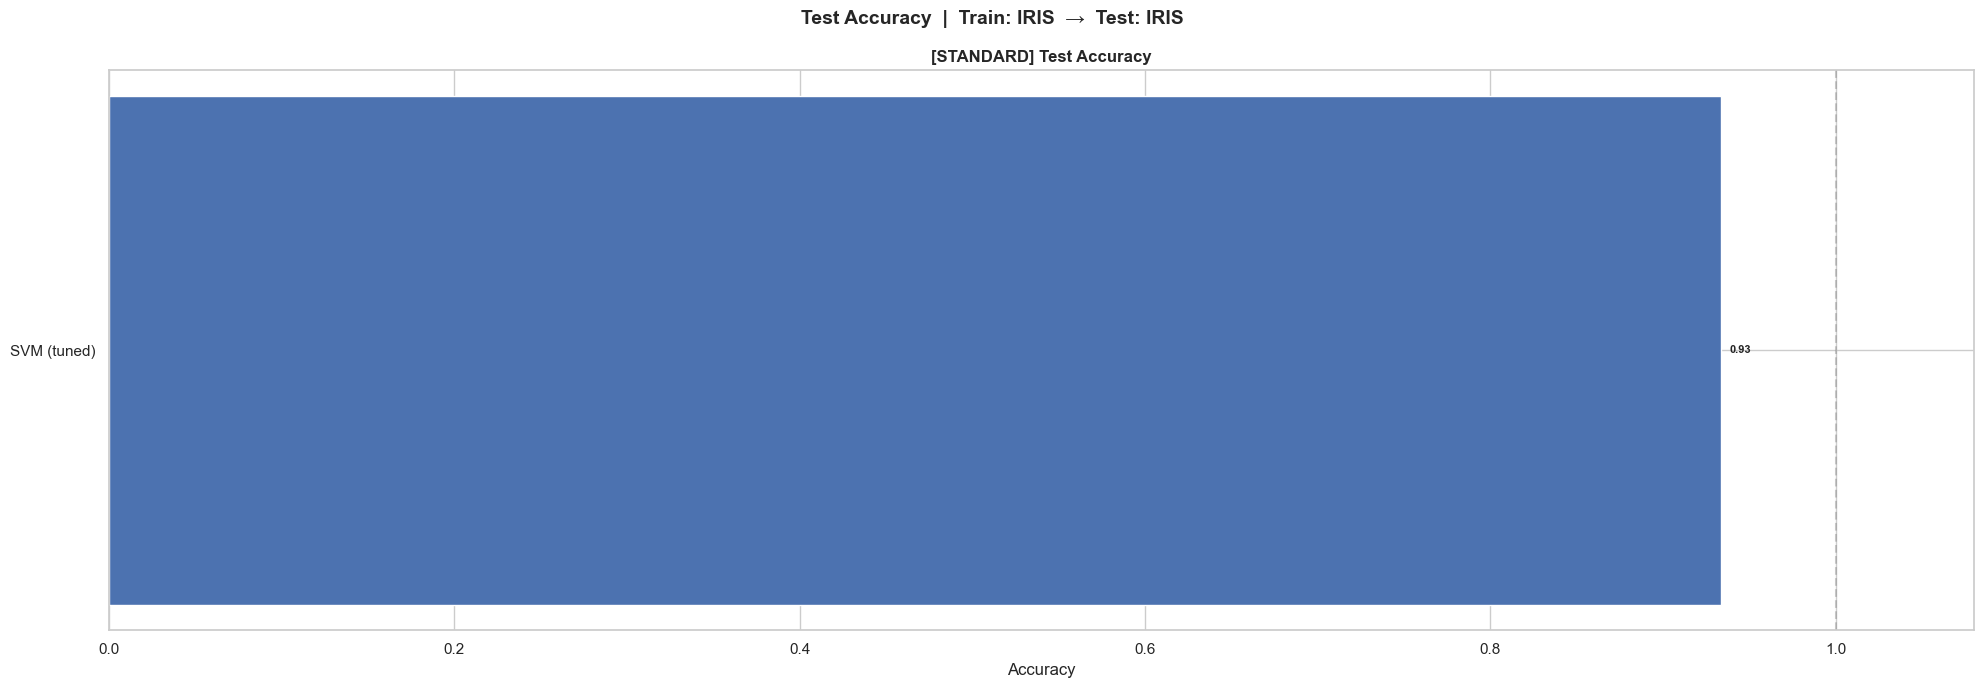

In [6]:
scalers_avail = [s for s in ['raw','minmax','standard'] if s in all_models]
fig, axes = plt.subplots(1, len(scalers_avail), figsize=(20, 7), sharey=True)
if len(scalers_avail) == 1:
    axes = [axes]
for idx, sn in enumerate(scalers_avail):
    subset = df_test[df_test['Scaler'] == sn]
    bars   = axes[idx].barh(subset['Model'], subset['Accuracy'],
                             color=COLORS[:len(subset)], edgecolor='white', height=0.6)
    axes[idx].set_title(f'[{sn.upper()}] Test Accuracy', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Accuracy')
    axes[idx].set_xlim(0.0, 1.08)
    axes[idx].axvline(x=1.0, color='gray', linestyle='--', alpha=0.4)
    for bar, row in zip(bars, subset.itertuples()):
        axes[idx].text(row.Accuracy + 0.005, bar.get_y() + bar.get_height()/2,
                       f'{row.Accuracy:.2f}', va='center', fontsize=8, fontweight='bold')
plt.suptitle(
    f'Test Accuracy  |  Train: {TRAIN_DATA_NAME.upper()}  →  Test: {TEST_DATA_NAME.upper()}',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR,
    f'{TRAIN_DATA_NAME}__test_{TEST_DATA_NAME}_plot_accuracy.png'), bbox_inches='tight')
plt.show()

## Bước 16: Confusion Matrix – Best Model


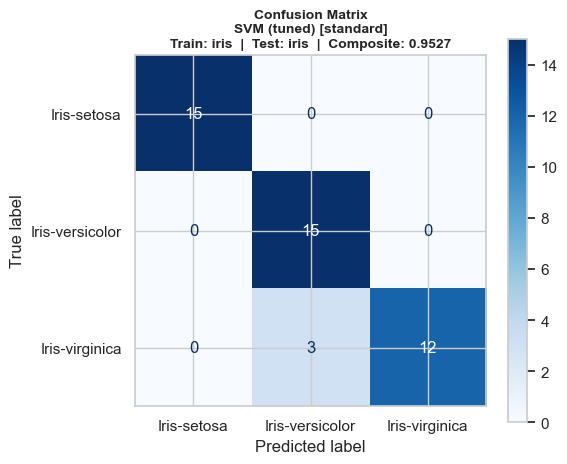


=== Classification Report ===
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.83      1.00      0.91        15
 Iris-virginica       1.00      0.80      0.89        15

       accuracy                           0.93        45
      macro avg       0.94      0.93      0.93        45
   weighted avg       0.94      0.93      0.93        45



In [7]:
best_sn = best_overall['scaler']
X_test, y_test = load_test(TEST_FILES[best_sn])
y_pred  = best_overall['model'].predict(X_test)
classes = np.unique(y_test)

fig, ax = plt.subplots(figsize=(6, 5))
cm   = confusion_matrix(y_test, y_pred, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(
    f'Confusion Matrix\n{best_overall["name"]} [{best_sn}]\n'
    f'Train: {TRAIN_DATA_NAME}  |  Test: {TEST_DATA_NAME}  |  Composite: {best_overall["composite"]:.4f}',
    fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR,
    f'{TRAIN_DATA_NAME}__test_{TEST_DATA_NAME}_plot_cm.png'), bbox_inches='tight')
plt.show()
print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=classes))

## Bước 17: ROC Curves


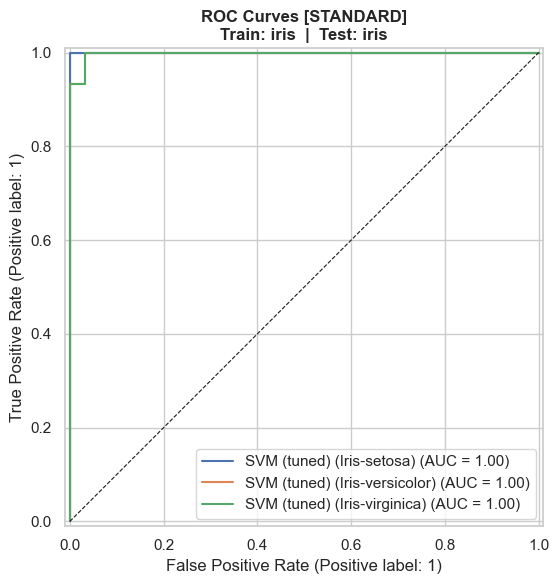

In [8]:
X_test, y_test = load_test(TEST_FILES[best_sn])
fig, ax = plt.subplots(figsize=(8, 6))
# Vẽ ROC curve cho từng lớp theo chiến lược OvR (one-vs-rest)
classes_list = np.unique(y_test)
for model_name, est in all_models[best_sn].items():
    if not hasattr(est, 'predict_proba'):
        continue
    y_prob = est.predict_proba(X_test)
    for i, cls in enumerate(est.classes_):
        RocCurveDisplay.from_predictions(
            (y_test == cls).astype(int), y_prob[:, i],
            ax=ax, name=f'{model_name} ({cls})')
ax.plot([0,1],[0,1],'k--', lw=0.8)
ax.set_title(f'ROC Curves [{best_sn.upper()}]\nTrain: {TRAIN_DATA_NAME}  |  Test: {TEST_DATA_NAME}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR,
    f'{TRAIN_DATA_NAME}__test_{TEST_DATA_NAME}_plot_roc.png'), bbox_inches='tight')
plt.show()

## Bước 18: Ghi test_log.xlsx


File `test_log.xlsx` lưu kết quả test chi tiết theo từng scaler và tổng hợp.
Sheet `Lich_su_chay` ghi thêm vào mỗi lần chạy — không ghi đè —
để theo dõi được hiệu năng qua nhiều lần thực nghiệm.

In [9]:
# Lịch sử chạy – nối thêm, không ghi đè
df_exp_info = pd.DataFrame([{
    'Thời gian'     : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'Train data'    : TRAIN_DATA_NAME,
    'Test data'     : TEST_DATA_NAME,
    'Best model'    : best_overall['name'],
    'Best scaler'   : best_overall['scaler'],
    'Composite'     : best_overall['composite'],
    'CV Composite'  : cv_metrics.get('Composite', np.nan),
    'Custom samples': 0,
    'Append custom' : False,
}])

file_exists = os.path.exists(TEST_LOG)
if file_exists:
    try:
        df_old     = pd.read_excel(TEST_LOG, sheet_name='Lich_su_chay')
        df_history = pd.concat([df_old, df_exp_info], ignore_index=True)
    except Exception:
        df_history = df_exp_info
else:
    df_history = df_exp_info

# Bang_diem_test: tất cả model x scaler xếp theo Composite
df_score_sheet = df_test[['Scaler','Model','Accuracy','F1','ROC_AUC','Composite','Labeled samples']] \
    .sort_values('Composite', ascending=False).reset_index(drop=True)

with pd.ExcelWriter(TEST_LOG, engine='openpyxl', mode='w') as writer:
    df_history.to_excel(writer,       sheet_name='Lich_su_chay',  index=False)
    df_score_sheet.to_excel(writer,   sheet_name='Bang_diem_test', index=False)
    if not df_all_preds.empty:
        df_all_preds.to_excel(writer, sheet_name='Predictions',   index=False)

label = '🆕 Tạo file mới' if not file_exists else '➕ Cập nhật file'
print(f'{label}: {os.path.basename(TEST_LOG)}')
print(f'⏱  Thời gian ghi: {df_exp_info["Thời gian"].iloc[0]}')
from openpyxl import load_workbook as _lw
_wb = _lw(TEST_LOG)
print('📋 Cấu trúc:')
for i, sh in enumerate(_wb.sheetnames):
    print(f'   Sheet {i+1}: {sh}')
_wb.close()


➕ Cập nhật file: iris__test_iris_log.xlsx
⏱  Thời gian ghi: 2026-04-03 14:31:10
📋 Cấu trúc:
   Sheet 1: Lich_su_chay
   Sheet 2: Bang_diem_test
   Sheet 3: Predictions


## Tổng kết thực nghiệm Test

In [10]:
print('=' * 65)
print('TỔNG KẾT TEST')
print('=' * 65)
print(f'⏱  Thời gian hoàn thành: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'\n📌 Cấu hình:')
print(f'   Model từ  : model/{TRAIN_DATA_NAME}/')
print(f'   Test trên : {TEST_DATA_NAME}')
print(f'\n🏆 Model tốt nhất:')
print(f'   Tên       : {best_overall["name"]}')
print(f'   Scaler    : {best_overall["scaler"]}')
print(f'   Composite : {best_overall["composite"]:.4f}')
print(f'\n📁 File kết quả (exps_/):')
print(f'   {os.path.basename(TEST_LOG)}')
for suffix in ['plot_accuracy', 'plot_cm', 'plot_roc']:
    print(f'   {TRAIN_DATA_NAME}__test_{TEST_DATA_NAME}_{suffix}.png')
print('=' * 65)

TỔNG KẾT TEST
⏱  Thời gian hoàn thành: 2026-04-03 14:31:10

📌 Cấu hình:
   Model từ  : model/iris/
   Test trên : iris

🏆 Model tốt nhất:
   Tên       : SVM (tuned)
   Scaler    : standard
   Composite : 0.9527

📁 File kết quả (exps_/):
   iris__test_iris_log.xlsx
   iris__test_iris_plot_accuracy.png
   iris__test_iris_plot_cm.png
   iris__test_iris_plot_roc.png
